The weight w found: [ 0.60414341 -0.3783685 ]
The free coefficient b was found.: -1.5019999999999454
SVM accuracy on the test set: 100.00%



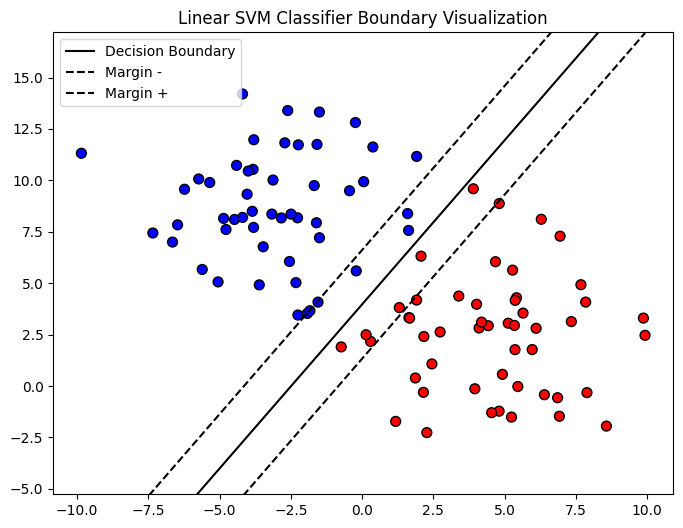

In [3]:
import numpy as np
from sklearn import datasets
import matplotlib.pyplot as plt

def accuracy(y_true, y_pred):
    return np.sum(y_true == y_pred) / len(y_true)

#prepare train set, test set
def train_test_split(X, y, test_size=0.2):
    indices = np.arange(X.shape[0])
    np.random.shuffle(indices)
    split_idx = int(len(indices) * (1 - test_size))
    train_idx, test_idx = indices[:split_idx], indices[split_idx:]
    return X[train_idx], X[test_idx], y[train_idx], y[test_idx]

#SVM model
class mySVM:
    def __init__(self, learning_rate=0.001, lambda_param=0.01, n_iters=1000):
        self.lr = learning_rate
        self.lambda_param = lambda_param
        self.n_iters = n_iters
        self.w = None
        self.b = None

    def fit(self, X, y):
        n_samples, n_features = X.shape
        y_transformed = np.where(y <= 0, -1, 1)
        
        self.w = np.zeros(n_features)
        self.b = 0

        for _ in range(self.n_iters):
            for idx, x_i in enumerate(X):
                condition = y_transformed[idx] * (np.dot(x_i, self.w) - self.b) >= 1
                if condition:
                    self.w -= self.lr * (2 * self.lambda_param * self.w)
                else:
                    self.w -= self.lr * (2 * self.lambda_param * self.w - np.dot(x_i, y_transformed[idx]))
                    self.b -= self.lr * y_transformed[idx]

    def predict(self, X):
        approx = np.dot(X, self.w) - self.b
        return np.where(approx >= 0, 1, 0)

#sample
X, y = datasets.make_blobs(n_samples=100, n_features=2, centers=2, cluster_std=2.8, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

#train model
clf = KaggleSVM(learning_rate=0.001, lambda_param=0.05, n_iters=1000)
clf.fit(X_train, y_train)

predictions = clf.predict(X_test)
print(f"The weight w found: {clf.w}")
print(f"The free coefficient b was found.: {clf.b}")
print(f"SVM accuracy on the test set: {accuracy(y_test, predictions) * 100:.2f}%\n")

#visualize svm
def visualize_svm():
    def get_hyperplane_value(x, w, b, offset):
        return (-w[0] * x + b + offset) / w[1]

    fig = plt.figure(figsize=(8,6))
    ax = fig.add_subplot(1, 1, 1)
    plt.scatter(X[:, 0], X[:, 1], marker="o", c=y, cmap="bwr", s=50, edgecolors="k")

    x0_1 = np.amin(X[:, 0])
    x0_2 = np.amax(X[:, 0])

    x1_1 = get_hyperplane_value(x0_1, clf.w, clf.b, 0)
    x1_2 = get_hyperplane_value(x0_2, clf.w, clf.b, 0)

    x1_1_m = get_hyperplane_value(x0_1, clf.w, clf.b, -1)
    x1_2_m = get_hyperplane_value(x0_2, clf.w, clf.b, -1)

    x1_1_p = get_hyperplane_value(x0_1, clf.w, clf.b, 1)
    x1_2_p = get_hyperplane_value(x0_2, clf.w, clf.b, 1)

    ax.plot([x0_1, x0_2], [x1_1, x1_2], "k-", label="Decision Boundary")
    ax.plot([x0_1, x0_2], [x1_1_m, x1_2_m], "k--", label="Margin -")
    ax.plot([x0_1, x0_2], [x1_1_p, x1_2_p], "k--", label="Margin +")

    x1_min = np.amin(X[:, 1])
    x1_max = np.amax(X[:, 1])
    ax.set_ylim([x1_min - 3, x1_max + 3])

    plt.title("Linear SVM Classifier Boundary Visualization")
    plt.legend()
    plt.show()

visualize_svm()